In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

def ProcessDataFile(filepath,TREE_NAME="ftree",plotPulses=False,branchesNameList=[],expPulse=True,numOfSamples=120,numOfPulses=1000):
    
    # --- 2. FILE & TREE ACCESS ---
    # Use 'with' for safe file handling
    segregatedCharge=[]
    hei=[]
    rows=5
    cols=5
    #plotPulses=True
    listOfPulses=[]
    plt.figure(figsize=(16,16))
    #branchList=['Energy','EnergyShort','Samples']
    #branchList=['Samples','Pulse']
    branchList=branchesNameList
    
    counter=0
    
    timingSamples = np.linspace(0,300,300)
    listOfSampledPulses=[]

    listOfSampledPulses=[]
    
    with uproot.open(filepath) as file:
        tree = file[TREE_NAME]
        
    
        # --- 3. DATA READING (Optimized) ---
        # Read only the first event (entry_stop=1) and the 'Samples' branch
        if plotPulses:
            data = tree.arrays(
                branchList, 
                entry_start=0, 
                entry_stop=numOfPulses, 
                library="ak"
            )
        else:
            data = tree.arrays(
                branchList,
                #entry_start=0, 
                #entry_stop=5000, 
                library="ak"
            )
        print("Total num of events : ",len(data))
        '''
        print(data["Energy"])
        binss=np.linspace(0,200,500)
        plt.hist(data["Energy"],histtype='step',bins=binss)
        plt.yscale("log")
        '''
        
        return data
        '''
        timePts = np.array([])
        pulse=np.array([])
        #print(data)
        '''
        
        '''
        for pulseNum in range(0,len(data)):
            
            pulse=data[pulseNum][pulseBranchName]
            #print(len(pulse))
            #print(pulse)
            
            #print(len(pulse))

           
            
            if len(pulse) > 16:
                #if not expPulse:
                #    pulse = np.concatenate((np.full(16,pulse[0]), pulse))
                #print(len(pulse))
                pulse=subtract_baseline(pulse,expPulse=expPulse)
                mask = pulse < 0;
                pulse=pulse[mask]

                                  
            #if len(pulse) > 10 and pulseNum < 16:
            if len(pulse) > 16 :
                padding_amount = numOfSamples - len(pulse)
                # Pad (0 at the start, padding_amount at the end)
                pulse = np.pad(pulse, (0, padding_amount), mode='constant')
                #print("@@@@@@@@@@@@@@@@@@@@@@@@@@")
                #print(pulse)
                #continue
                #if not expPulse:
                #    pulse = -1.*pulse
                timePts=np.linspace(0,len(pulse),len(pulse))

                #print("@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@")
                #print(pulse)
                
                #listOfSampledPulses.append(pulse.tolist())
                #counter += 1
                #plt.subplot(4,4,counter)
                #plt.plot(timePts,pulse)
                try:
                    popt=FitPulse(np.asarray(timePts.tolist()),np.asarray(pulse.tolist()))
                    fitted_pulse = pulse_model(timePts, *popt)
                    #sampled_pulse = pulse_model(timingSamples, *popt)
                    #listOfSampledPulses.append(max_normalize(sampled_pulse))
                    #listOfSampledPulses.append(sampled_pulse)
                    
                    r2 = r2_score(pulse, fitted_pulse)
                    if 0 and r2 > 0.9:
                        print(f"================= {counter} ======================")
                        print(f"Pulse length : {len(counts)}")
                        print(f"R-squared: {r2:.3f}")

                    
                    if r2 > 0.9 :
                        counter+=1
                        listOfSampledPulses.append(pulse.tolist())
                        #print(len(pulse))
                        #pulseLenList.append(len(counts))
                        if counter <= 16:
                            plt.subplot(4,4,counter)
                            #plt.scatter(timePts,pulse,marker=".",color="blue")
                            plt.plot(timePts,pulse)
                            plt.plot(timePts,fitted_pulse,'r-')
                            #counter += 1
                            #plt.subplot(4,4,counter)
                            #plt.plot(timingSamples,sampled_pulse,marker=".",color="green")
                except ValueError as e:
                    #print(f"Skipping event due to bounds error: {e}")
                    continue  # Skips the rest of this loop iteration
                except RuntimeError:
                    #print("Skipping event: Fit failed to converge.")
                    continue

        #print(listOfSampledPulses)
        listOfSampledPulses = np.array(listOfSampledPulses)
        #result = np.zeros((len(ragged_data), N), dtype=int)
        
        return listOfSampledPulses,timePts
        '''

In [2]:
SOURCE_FILE_PATH="../SampleData/DataF_TPD_PS_Na22_Waves_5min.root"
branchesNameList=["Energy","CalibEnergy","Samples"]
data=ProcessDataFile(SOURCE_FILE_PATH,"Data_F",branchesNameList=branchesNameList,plotPulses=False,numOfPulses=100)

Total num of events :  262556


<Figure size 1600x1600 with 0 Axes>

Detected Compton Edges at: [14.1, 47.2, 84.4, 98.5, 112, 127, 150, 170, 194] keV


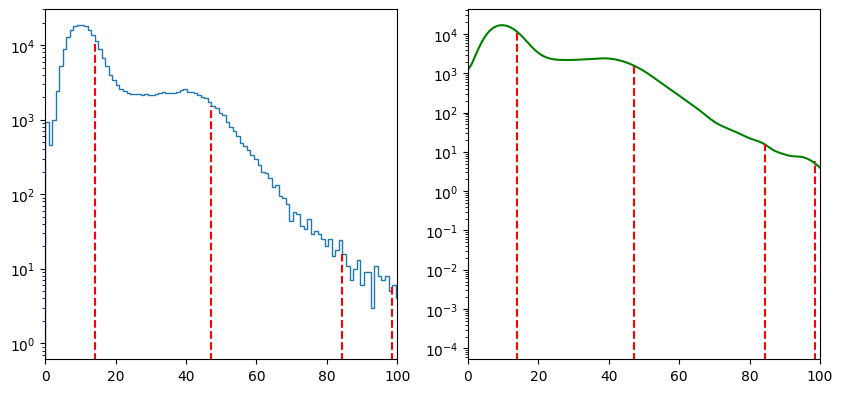

In [17]:
plt.figure(figsize=(10,10))
binss=np.linspace(0,200,200)
#counts,timing=np.histogram(data["CalibEnergy"],bins=200)
counts,timing=np.histogram(data["Energy"],bins=binss)
arrLen=0
if len(counts) < len(timing):
    arrLen=len(counts)
else:
    arrLen=len(timing)


from scipy.ndimage import gaussian_filter1d
# Increase sigma for more smoothing
y_smooth = gaussian_filter1d(counts[:arrLen], sigma=2)
plt.subplot(2,2,2)
plt.plot(timing[:arrLen], y_smooth,"g-")
plt.yscale("log")
#plt.ylim(1,100000)
plt.xlim(0,100)


dydx = np.gradient(y_smooth, timing[:len(y_smooth)])
'''
edge_index = np.argmin(dydx)
compton_energy = timing[edge_index]

print(f"Compton Edge Energy: {compton_energy} keV")
'''

from scipy.signal import find_peaks
peaks, properties = find_peaks(-dydx, 
                               height=0,         # Only positive slopes in -dydx
                               distance=5,      # Min distance between edges in bins
                               prominence=0.1)   # Filter out minor fluctuations

plt.subplot(2,2,1)
#plt.hist(data["CalibEnergy"],histtype='step',bins=500)
plt.hist(data["Energy"],histtype='step',bins=binss)
#plt.plot(timing[:arrLen],counts[:arrLen],"r-")
plt.yscale("log")
plt.xlim(0,100)
# 4. Extract energy values
edge_energies = timing[peaks]
plt.vlines(x=edge_energies, 
           ymin=0, 
           ymax=counts[peaks], 
           colors='red', 
           linestyles='dashed', 
           label='Compton Edges')

plt.subplot(2,2,2)
plt.vlines(x=edge_energies, 
           ymin=0, 
           ymax=counts[peaks], 
           colors='red', 
           linestyles='dashed', 
           label='Compton Edges')
print(f"Detected Compton Edges at: {edge_energies} keV")